In [1]:
import os
import numpy as np
from PIL import Image
import cv2
from tqdm import tqdm
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torchvision import models

In [2]:
import os
import numpy as np
from PIL import Image
import cv2
from tqdm import tqdm

# Define paths to your tiled data
base_path = "/home/student/sky-scan/data"
original_dir = f"{base_path}/patch"
binary_dir = f"{base_path}/patch-binary"
color_dir = f"{base_path}/patch-texture"
images_, binary_masks_, color_masks_ = [], [], []
def load_tiled_data(original_dir, binary_dir, color_dir):

    filenames = sorted(os.listdir(original_dir))

    for filename in tqdm(filenames, desc="Loading tiles", unit="tile"):
        # Load original tile
        img_path = os.path.join(original_dir, filename)
        image = Image.open(img_path).convert("RGB")
        images_.append(np.array(image) / 255.0)  # Normalize to [0, 1]

        # Load binary mask tile
        binary_path = os.path.join(binary_dir, filename)
        binary = Image.open(binary_path).convert("L")  # Grayscale
        binary_masks_.append(np.array(binary) / 255.0)  # 0 or 1

        # Load color mask tile
        color_path = os.path.join(color_dir, filename)
        color = Image.open(color_path).convert("RGB")
        color_masks_.append(np.array(color) / 255.0)  # Normalize to [0, 1]

images = np.array(images_)
binary_masks = np.array(binary_masks_)
color_masks = np.array(color_masks_)

load_tiled_data(original_dir, binary_dir, color_dir)

Loading tiles: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16200/16200 [02:00<00:00, 134.47tile/s]


In [3]:
def get_largest_contour_square(image_input, black_tolerance=10):
    """
    Extract the largest contour and return a normalized 20x20 square region with its label.

    Parameters:
    - image_input: numpy array, input image in BGR format
    - black_tolerance: int, tolerance for black color detection

    Returns:
    - normalized_square: 20x20 numpy array of the extracted region
    - label: str, label based on dominant color (rough, average, smooth)
    """
    # Work on a copy of the input image
    image = image_input.copy()

    # Convert BGR to RGB for color processing
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create mask for non-black pixels with tolerance
    black_mask = np.all(np.abs(image_rgb - [0, 0, 0]) <= black_tolerance, axis=-1)

    # Create working copy with white background
    masked_image = image_rgb.copy()
    masked_image[black_mask] = [255, 255, 255]

    # Convert to grayscale and create binary image
    gray = cv2.cvtColor(masked_image, cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 254, 255, cv2.THRESH_BINARY_INV)

    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, "No contour"

    # Find the largest contour by area
    largest_contour = max(contours, key=cv2.contourArea)

    # Skip if largest contour is too small
    if cv2.contourArea(largest_contour) < 50:
        return None, "Small contour"

    # Find enclosing circle
    (x, y), radius = cv2.minEnclosingCircle(largest_contour)
    center = (int(x), int(y))
    radius = int(radius)  # Use full radius for square

    # Calculate square bounds
    half_size = int(radius * 1.414 / 2)  # Half of square diagonal (radius * sqrt(2))
    x_min = max(0, center[0] - half_size)
    x_max = min(image.shape[1], center[0] + half_size)
    y_min = max(0, center[1] - half_size)
    y_max = min(image.shape[0], center[1] + half_size)

    # Extract square region
    square_region = image_rgb[y_min:y_max, x_min:x_max]

    # Resize to 20x20
    normalized_square = cv2.resize(square_region, (20, 20), interpolation=cv2.INTER_AREA)

    # Determine the label based on the dominant color
    dominant_color = np.mean(normalized_square, axis=(0, 1))
    if np.all(dominant_color < [85, 85, 85]):
        label = "rough"
    elif np.all(dominant_color < [170, 170, 170]):
        label = "average"
    else:
        label = "smooth"

    return normalized_square, label

def extract_patches_and_labels(images, masks, target_size=(20, 20)):
    """
    Extract 20x20 patches and labels from all images.

    Parameters:
    - images: numpy array of original images
    - masks: numpy array of mask images
    - target_size: tuple of (height, width) for the extracted patches

    Returns:
    - patches: list of normalized 20x20 patches
    - labels: list of labels for the patches
    """
    patches = []
    labels = []

    for idx in tqdm(range(len(images)), desc="Extracting patches"):
        # Get image and mask
        img = images[idx]
        mask_rgb = masks[idx]

        # Convert mask to uint8 for OpenCV
        mask_rgb_cv = (mask_rgb * 255).astype(np.uint8)

        # Get normalized square from largest contour
        normalized_square, label = get_largest_contour_square(
            cv2.cvtColor(mask_rgb_cv, cv2.COLOR_RGB2BGR),
            black_tolerance=10
        )

        if normalized_square is None:
            # If no valid contour, resize the mask to 20x20
            normalized_square = cv2.resize(mask_rgb_cv, target_size, interpolation=cv2.INTER_AREA)
            label = "no_contour"

        patches.append(normalized_square)
        labels.append(label)

    return patches, labels
# Extract patches and labels
patches, labels = extract_patches_and_labels(binary_masks_, color_masks_)

patches_array = np.array(patches)



Extracting patches: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16200/16200 [01:12<00:00, 223.51it/s]


In [4]:
label_map = {'rough': 0, 'average': 1, 'smooth': 2, 'no_contour': 3}
numerical_labels = [label_map[label] for label in labels]

# Print shapes for debugging
print(f"Shape of patches array: {patches_array.shape}")
print(f"Shape of labels array: {len(numerical_labels)}")
# Convert to PyTorch tensors
X = torch.FloatTensor(patches_array.transpose(0, 3, 1, 2))  # [N, C, H, W]
y = torch.LongTensor(numerical_labels)  # [N]

# Print shapes of tensors for debugging
print(f"Shape of X tensor: {X.shape}")
print(f"Shape of y tensor: {y.shape}")

Shape of patches array: (16200, 20, 20, 3)
Shape of labels array: 16200
Shape of X tensor: torch.Size([16200, 3, 20, 20])
Shape of y tensor: torch.Size([16200])


In [5]:


# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create data loaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Load and modify ResNet18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with tracking
num_epochs = 40
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch"):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_loss)
    train_accuracies.append(train_accuracy)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    val_loss = val_loss / len(test_dataset)
    val_accuracy = 100 * correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

# Save the model
torch.save(model.state_dict(), "texture_model.pth")

/home/student/miniconda3/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/student/miniconda3/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/40: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 405/405 [00:07<00:00, 57.02batch/s]


Epoch 1/40, Train Loss: 0.2837, Train Acc: 88.86%, Val Loss: 0.1539, Val Acc: 93.49%


Epoch 2/40: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 405/405 [00:04<00:00, 84.95batch/s]


Epoch 2/40, Train Loss: 0.1740, Train Acc: 93.06%, Val Loss: 0.1604, Val Acc: 93.73%


Epoch 3/40: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 405/405 [00:04<00:00, 85.16batch/s]


...

Epoch 38/40, Train Loss: 0.0231, Train Acc: 99.16%, Val Loss: 0.1042, Val Acc: 96.73%


Epoch 39/40: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 405/405 [00:04<00:00, 85.81batch/s]


Epoch 39/40, Train Loss: 0.0165, Train Acc: 99.41%, Val Loss: 0.1072, Val Acc: 96.60%


Epoch 40/40: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 405/405 [00:04<00:00, 81.96batch/s]


Epoch 40/40, Train Loss: 0.0173, Train Acc: 99.44%, Val Loss: 0.1261, Val Acc: 96.20%


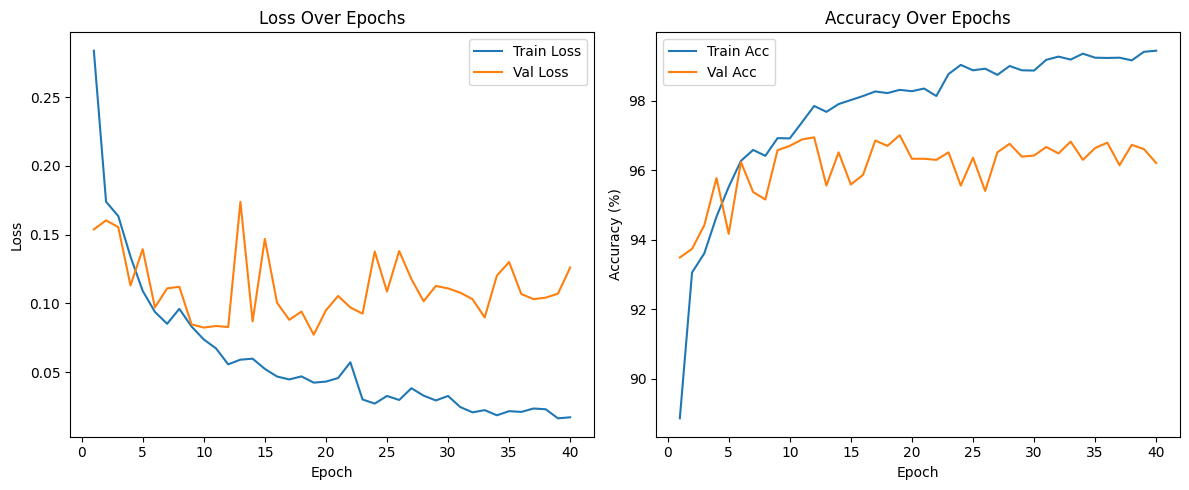

In [6]:
import matplotlib.pyplot as plt

# Plot training graphs
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Acc")
plt.plot(range(1, num_epochs + 1), val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

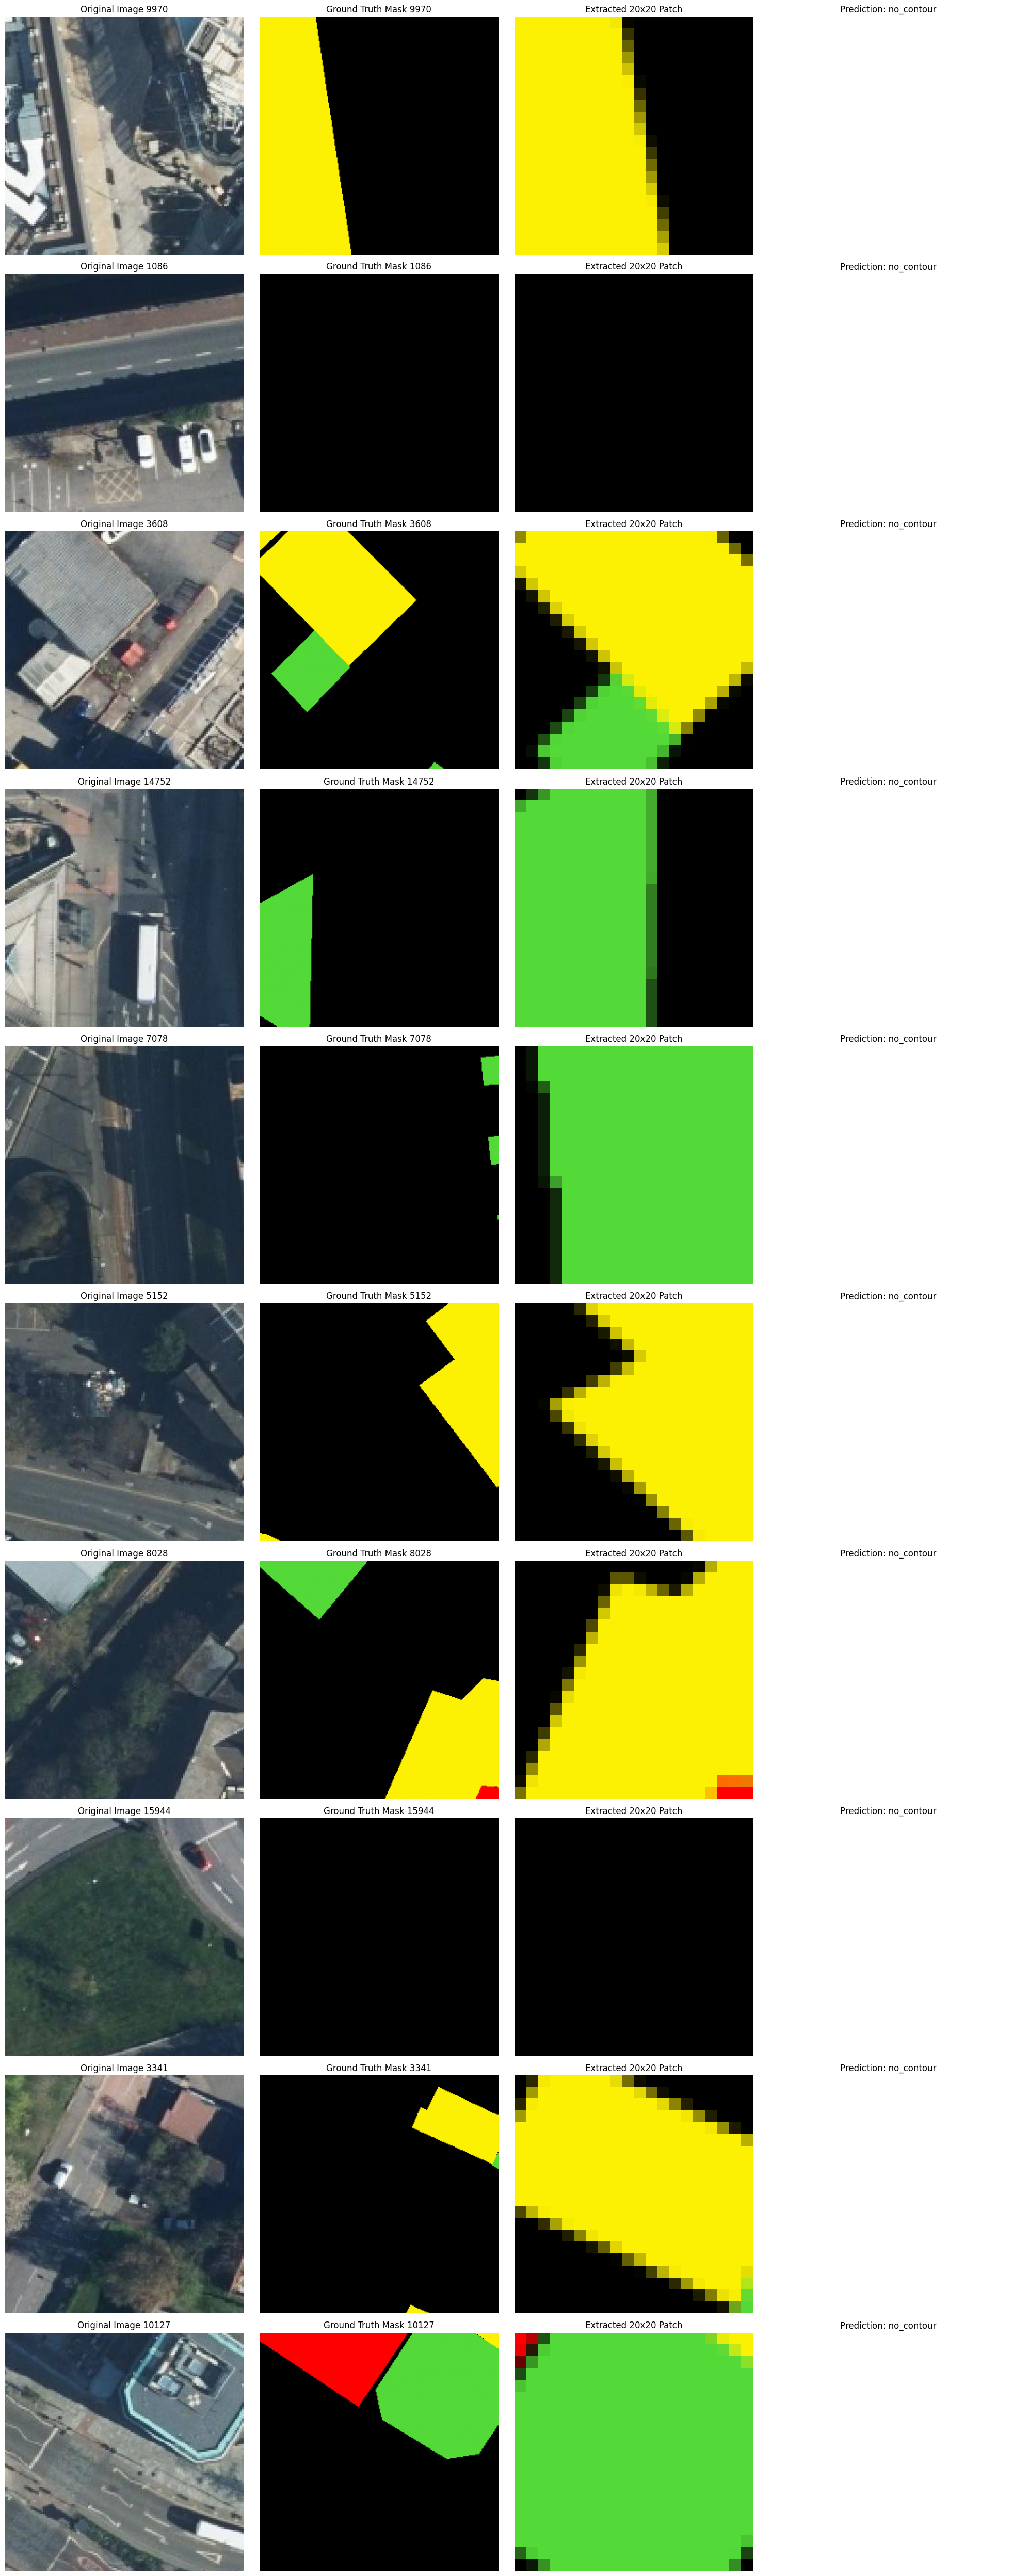

In [10]:
target_size = (20, 20)

def display_random_samples_with_predictions(model, original_images, color_masks, label_map, num_samples=10):
    """
    Display random samples with original images, ground truth masks, predictions, and extracted patches.
    """
    model.eval()
    total_images = len(original_images)
    random_indices = np.random.choice(total_images, num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))

    label_map_reverse = {v: k for k, v in label_map.items()}
    patches = []
    patch_indices = []

    for idx, sample_idx in enumerate(random_indices):
        # Original image
        orig_img = original_images[sample_idx]
        orig_img = np.clip(orig_img, 0, 1)
        axes[idx, 0].imshow(orig_img)
        axes[idx, 0].set_title(f'Original Image {sample_idx}')
        axes[idx, 0].axis('off')

        # Ground truth mask
        mask_img = color_masks[sample_idx]
        mask_img = np.clip(mask_img, 0, 1)
        axes[idx, 1].imshow(mask_img)
        axes[idx, 1].set_title(f'Ground Truth Mask {sample_idx}')
        axes[idx, 1].axis('off')

        # Extract patch
        mask_rgb_cv = (mask_img * 255).astype(np.uint8)
        normalized_square, label = get_largest_contour_square(
            cv2.cvtColor(mask_rgb_cv, cv2.COLOR_RGB2BGR),
            black_tolerance=10
        )

        if normalized_square is None:
            normalized_square = cv2.resize(mask_rgb_cv, target_size, interpolation=cv2.INTER_AREA)
            label = "no_contour"

        patches.append(normalized_square)
        patch_indices.append(idx)

        # Display extracted patch
        axes[idx, 2].imshow(normalized_square)
        axes[idx, 2].set_title('Extracted 20x20 Patch')
        axes[idx, 2].axis('off')

    # Prepare batch input
    patches_array = np.array(patches).transpose(0, 3, 1, 2) / 255.0
    input_tensor = torch.FloatTensor(patches_array).to(device)

    # Batch prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)

    for idx, pred in zip(patch_indices, predicted):
        pred_label = label_map_reverse[pred.item()]

        # Create prediction mask
        pred_color = np.array(label_map[pred_label])
        pred_mask = np.ones_like(original_images[idx]) * pred_color.reshape(1, 1, -1)

        axes[idx, 3].imshow(pred_mask)
        axes[idx, 3].set_title(f'Prediction: {pred_label}')
        axes[idx, 3].axis('off')

    plt.tight_layout()
    plt.show()

# Set random seed for reproducibility
np.random.seed(42)

# Display random samples with predictions
display_random_samples_with_predictions(model, images_, color_masks_, label_map)